# Intrduction
The dataset has been provided by a retail business to analyze its sales performance and identify key business challenges. Management is concerned that some products are selling in high volumes but are not generating sufficient revenue. Additionally, sales appear to be inconsistent over time, raising questions about whether the current product focus and strategy are effective.

The objective of this analysis is to evaluate overall sales performance, understand how sales behave over time, and identify which products are driving revenue. By analyzing product-level and time-based trends, this study aims to provide insights that can help the business assess its current strategy and identify areas for improvement.

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#import dataset
sales = pd.read_csv("retail_sales_data.csv", encoding = "cp1252")
sales.head(5)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [3]:
#see how our dataset looks
sales.shape

(2823, 25)

In [4]:
#checl colummn names
sales.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [5]:
#change column name to make it more appropriate
sales.rename(columns = {"YEAR_ID": "YEAR"}, inplace = True)
sales.rename(columns = {"month_name": "MONTH"}, inplace = True)

In [6]:
#change date to datetime format
sales['ORDERDATE'] = pd.to_datetime(sales['ORDERDATE'])

In [7]:
#calculate total revenue
total = sum(sales['SALES'])
total_m = total / 1000000
print(f"The total revenue generated is :${round(total_m, 2)}M")

The total revenue generated is :$10.03M


In [8]:
#add a month column 
sales['month_name'] = sales['ORDERDATE'].dt.month_name()

# 1. Overall Business Performance:
    First we will find how much business is making and check whether revenue is growing or declling over time.

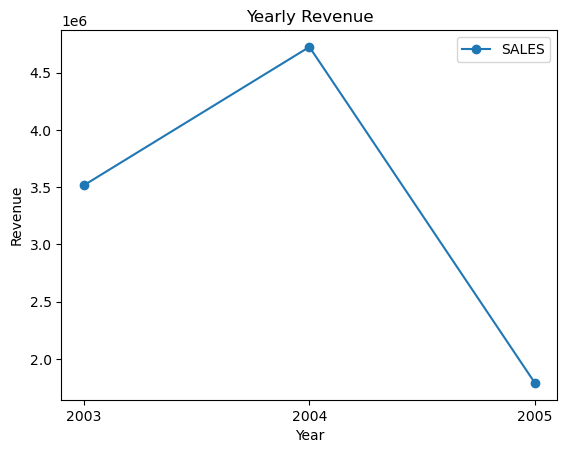

In [9]:
#calculate yearly revenue and store it in separate dataframe
yearly_revenue = sales.groupby('YEAR')['SALES'].sum().reset_index()

#plot line grapg to find revenue's growth
ax = yearly_revenue.plot(kind = 'line', x = 'YEAR', y = 'SALES', marker = 'o')
ax.set_xticks(yearly_revenue["YEAR"])
ax.set_xticklabels(yearly_revenue["YEAR"])
plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

In [10]:
#calculate total revenue
total_revenue = sum(yearly_revenue['SALES'])
print("Total revenue generated :", total_revenue)

#calculate yearly percentage 
#2003 yearly contribution
y03_per = (yearly_revenue['SALES'][0] / total_revenue) * 100
print(f"{yearly_revenue['YEAR'][0]} has contributed {round(y03_per, 2)}% in the total revenue.")

#2004 yearly contribution
y04_per = (yearly_revenue['SALES'][1] / total_revenue) * 100
print(f"{yearly_revenue['YEAR'][1]} has contributed {round(y04_per, 2)}% in the total revenue.")

#2005 yearly contribution
y04_per = (yearly_revenue['SALES'][2] / total_revenue) * 100
print(f"{yearly_revenue['YEAR'][2]} has contributed {round(y04_per, 2)}% in the total revenue.")

Total revenue generated : 10032628.85
2003 has contributed 35.06% in the total revenue.
2004 has contributed 47.09% in the total revenue.
2005 has contributed 17.86% in the total revenue.


# Insights:
    The line graph clearly tells that the sales were grown in 2004 as compared to 2003 but sales dropped drastically in 2005.Insights from yearly revenue analysis:
1. The total revenue genrated is 10.03M.
2. In the year of 2003, the revenue contribution was 35.06% and generated 3.52M.
3. The revenue contribution increased from 35.06% to 47.09% in the year of 2004 and genrated 4.72M.
4. The 82%(8.24M) of the total revenue is generated by year 2003 and 2004 collectively.
5. In 2005, revenue contribution dropped almost 30% from the previous year to 17.86% and generateed 1.79M.

# 2. Product Performance
    In this section, product performance will be evaluated and answer the follwoing questions through data analysis:
 1. Which product generate the most revenue?
 2. Which products sell the highest quantity?
 3. Is there high selling volume and low revenue generation?
 4. Is there high revenue generation but low selling volume?

# Which product generate the most revenue?

In [11]:
#top performing product
#as there is no specific coluumn for product name,so I will use productline column
top_product = sales.groupby('PRODUCTLINE')['SALES'].sum().reset_index()
#convert sale's unit into millions
top_product['SALES_M'] = top_product['SALES'] / 1000000

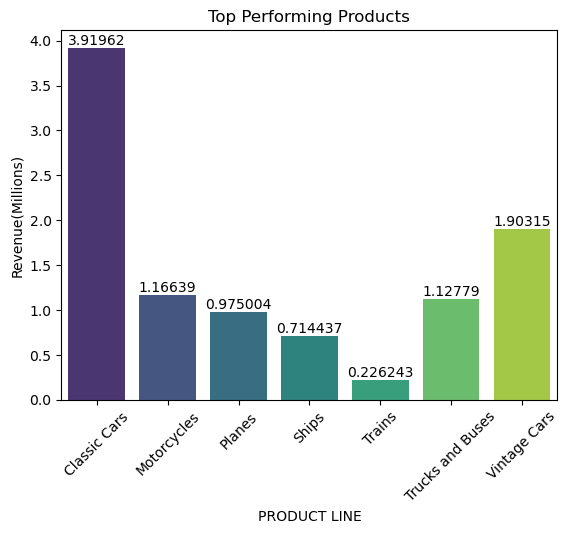

In [12]:
#plot bar plot to visualize top performing products
top_selling_bar = sns.barplot(x = 'PRODUCTLINE', y = 'SALES_M', data = top_product, hue = 'PRODUCTLINE', palette = 'viridis', dodge = False)
for container in top_selling_bar.containers:
    top_selling_bar.bar_label(container)
plt.title("Top Performing Products")
plt.xlabel("PRODUCT LINE")
plt.ylabel("Revenue(Millions)")
plt.xticks(rotation = 45)
top_selling_bar.legend_.remove()
plt.show()

In [13]:
#calculate total revenue
total_r = sum(top_product['SALES_M'])
#top performing product by revenue
top_p1 = (top_product['SALES_M'][0] / total_r) * 100
print(f"The contribution of top performing product to the revenue is : {round(top_p1, 2)}")

#2nd top performing product by revenue
top_p2 = (top_product['SALES_M'][6] / total_r) * 100
print(f"The contribution of 2nd top performing product to the revenue is : {round(top_p2, 2)}")

#3rd top performing product by revenue
top_p3 = (top_product['SALES_M'][1] / total_r) * 100
print(f"The contribution of 3rd top performing product to the revenue is : {round(top_p3, 2)}")

#worst performing product by revenue
worst_p1 = (top_product['SALES_M'][4] / total_r) * 100
print(f"The contribution of worst performing product to the revenue is : {round(worst_p1, 2)}")


The contribution of top performing product to the revenue is : 39.07
The contribution of 2nd top performing product to the revenue is : 18.97
The contribution of 3rd top performing product to the revenue is : 11.63
The contribution of worst performing product to the revenue is : 2.26


# Insights:
1. The 'Classic Cars' product line has out performed all other products as it has soley generated 3.91M of revenue.It has 39.07% of the total revenue.
2. The second most performing product line is 'Vintage Cars' which has contributed 18.97% of the total revenue and generated 1.90M.
3. The third most performing product line is 'Mototcycles' which has contributed 11.63% of the total revenue and generated 1.16M.
4. The 'Trains' product line is the worst performing product line as it has contributed 2.26% of total revenue by generating 0.22M.

In [14]:
#calculate the most sold product by qunatity
most_sold = sales.groupby('PRODUCTLINE')['QUANTITYORDERED'].sum().reset_index()

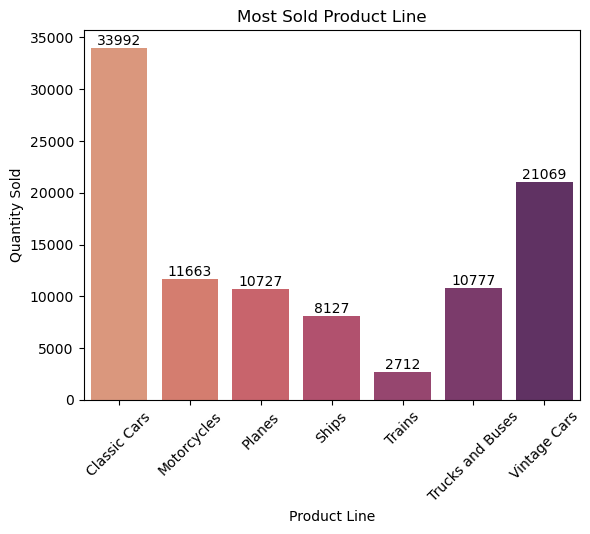

In [15]:
#use barplot to visualize most sold product by quantity
most_sold_products = sns.barplot(x = 'PRODUCTLINE', y = 'QUANTITYORDERED', data = most_sold, hue = 'PRODUCTLINE', palette = 'flare', dodge = False)
for container in most_sold_products.containers:
    most_sold_products.bar_label(container)
plt.title("Most Sold Product Line")
plt.xlabel("Product Line")
plt.ylabel("Quantity Sold")
plt.xticks(rotation = 45)
most_sold_products.legend_.remove()
plt.show()

In [16]:
#calcul total units sold
total_units = sum(most_sold['QUANTITYORDERED'])

#most sold product line share in total units sold
most_s1 = (most_sold['QUANTITYORDERED'][0] / total_units) * 100
print(f"The most sold product line is : {round(most_s1, 2)}%")

#second most sold product line share in total units sold
most_s2 = (most_sold['QUANTITYORDERED'][6] / total_units) * 100
print(f"The second most sold product line is : {round(most_s2, 2)}%")

#third most sold product line share in total units sold
most_s3 = (most_sold['QUANTITYORDERED'][1] / total_units) * 100
print(f"The most sold product line is : {round(most_s3, 2)}%")

#least sold product line
worst_s = (most_sold['QUANTITYORDERED'][4] / total_units) * 100
print(f"The most sold product line is : {round(worst_s, 2)}%")

The most sold product line is : 34.31%
The second most sold product line is : 21.27%
The most sold product line is : 11.77%
The most sold product line is : 2.74%


# Insights:
1. The 'Classic Cars' product line is the most selling product line as it has sold nearly 34,000 units and it has sold 34.31% of the total units sold.
2. The second most sold product line is 'Vintage Cars' which has contibuted by solding 21,069(21.27%) units of total units sold.
3. The 'Motorcycles' product line is at third spot by solding 11,663 units which make its share up to 11.77% of thr total units sold.
4. Th product line which has sold least number of units is 'Trains' as it has sold only 2712(2.74%) of the total units sold.

#  Is there high selling volume and low revenue generation?


# Is there high revenue generation but low selling volume?

The 'Top Performing Products' and 'Most Sold Product Line' barplots clearly shows that there is no such relationship.The top performing productline is 'Classic Cars' and the most sold productline is also the 'Classic Cars'.This behavioe is same for all the other product lines.There is no such productline which has high selling volume and low revenue generation and vice versa.

# Time-Based Analysis

1. Are there clear sales trends over time?
2. Do certain months or periods perform better?
3. Are there any unusual spikes or drop?

In [17]:
#monthly sales analysis
monthly_sales = sales.groupby(['ORDERDATE', 'YEAR','MONTH'])['SALES'].sum().reset_index()

#concatenate year and month column
monthly_sales["YEAR_MONTH"] = (monthly_sales["MONTH"] + " " + monthly_sales["YEAR"].astype(str))

#convert sales unit into millions
monthly_sales['SALES_M'] = round(monthly_sales['SALES'] / 1000000, 2)

#sort the orderdate
monthly_sales = monthly_sales.sort_values('ORDERDATE')
monthly_sales.head(6)

KeyError: 'MONTH'

In [ ]:
#calculate monthly sales
monthly_sales1 = monthly_sales.groupby(['YEAR_MONTH'])['SALES_M'].sum().reset_index()
#convert year_month column to datetime column
monthly_sales1['YEAR_MONTH_DT'] = pd.to_datetime(monthly_sales1['YEAR_MONTH'])
#sort months in order
monthly_sales1 = monthly_sales1.sort_values('YEAR_MONTH_DT')

In [ ]:
#calculate rolling average for 6-month time frame
monthly_sales1['rolling_6m'] = monthly_sales1['SALES_M'].rolling(6).mean()

In [ ]:
#plot line plot to analyze sales over time
plt.figure(figsize = (12, 5))
sns.lineplot(data = monthly_sales1, x = 'YEAR_MONTH', y = 'SALES_M')
sns.lineplot(data = monthly_sales1, x = 'YEAR_MONTH', y = 'rolling_6m', label = "6-Month Avg")
plt.title("Monthly Sales Over Time")
plt.xticks(rotation = 45)
plt.show()

#  Are there clear sales trends over time?

   Sales exhibit a mild upward trend over time. Although there are noticeable short-term fluctuations and occasional spikes, the rolling average shows no sustained decline and ends at a slightly higher level than it begins. This indicates modest overall growth across the observed period.

#  Do certain months or periods perform better?

Yes, certain periods perform better than others. The chart shows recurring spikes during specific months across consecutive years, suggesting the presence of seasonal patterns. In particular, sales tend to peak between July and November, indicating stronger performance during these months compared to the rest of the year.

#  Are there any unusual spikes or drop?

The chart shows recurring spikes during specific months across two consecutive years,suggesting the presence of seasonal patterns.Despite the short-term fluctuations, there is no evidence of a significant drop in sales over time suggesting that overall sales performance remains stable.

# 4. Customer & Market Signals
1. Are sales concentrated around a small number of products?
2. Do we have over-dependency on certain products?
3. Is our product mix healthy?

# Are sales concentrated around a small number of products?

Yes,sales are concentrated around a small number of  products.Out of seven product lines, three product lines sold 65% of the total units sold while the 'Classic Cars' product lines sold around 35% of the total units sold indicating that small group of products is the primary driver of overall sales performance.


# Do we have over-dependency on certain products?

Sales are highly concentrated among a small number of product lines, with three products accounting for approximately 65% of total units sold and Classic Cars alone contributing around 35%. This indicates over-dependency on key products, which presents both growth opportunities and potential risk if demand for these products declines.

# Is our product mix healthy?

The product mix shows moderate health, with strong performance from key product lines. However, sales are highly concentrated among a small number of products, indicating dependency risk. While top-performing products drive growth, diversification across lower-performing lines would improve overall product-mix balance and long-term stability.

# Business Risks And Opportunities

Which products should we:
1. Promote more?
2. Improve Pricing?
3. Consider Discontinuing?

Where can we increase revenue without increasing cost significantly?

The analysis suggests that revenue growth should focus on strengthening top-performing product lines through increased promotion and upselling. Pricing optimization opportunities exist for products with steady sales but lower revenue contribution. Low-performing products may be reviewed for repositioning or discontinuation, while revenue can be increased with minimal cost by leveraging seasonal peaks and cross-selling strategies.

# Conclusion

The analysis indicates that overall sales exhibit a mild upward trend over time, despite noticeable short-term fluctuations and seasonal spikes. Sales performance is largely driven by a small number of product lines, particularly Classic Cars, highlighting a moderate level of dependency within the product portfolio. While this concentration reflects strong demand for key products, it also introduces potential risk if demand for these products declines.
To support sustainable growth, the business should focus on strengthening top-performing products through targeted promotion and upselling, while optimizing pricing and positioning for lower-performing product lines. Leveraging seasonal demand patterns and improving product mix balance can help increase revenue without significantly raising operational costs.